## Exploratory Data Analysis (EDA) Project
## Retail Sales & Customer Behavior Analysis

### Problem Statement
A retail company wants to understand its sales performance, customer purchasing behavior, product preferences, and
sales trends using historical transaction data.
The company has provided a retail sales dataset containing information about transactions, customers, product
categories, prices, quantities, dates, and total transaction amounts.
Your task is to perform a complete Exploratory Data Analysis (EDA) to identify meaningful patterns, trends,
relationships, and business insights from the dataset.
The analysis should help the company answer questions such as which products and categories generate the highest
sales, which customer groups contribute most to revenue, how sales change over time, whether customer
demographics influence purchasing behavior, and what factors are associated with higher transaction values.
The final analysis should present meaningful visualizations, explain the business meaning behind the findings, and
provide actionable recommendations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Understanding

In [2]:
df = pd.read_excel('raw_dataset.xlsx')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
price_check = df['Quantity'] * df['Price per Unit'] == df['Total Amount']
price_check.value_counts()

True    1000
Name: count, dtype: int64

In [10]:
df[['Customer ID']].nunique()

Customer ID    1000
dtype: int64

In [11]:
bins = [18, 35, 50, 64]
labels = ['Adult', 'Middle Age', 'Senior']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

In [12]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Middle Age
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Middle Age
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Adult
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,Middle Age
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,Middle Age
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,Adult
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,Senior
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,Senior


## Customer Analysis

In [13]:
df['Age Group'].value_counts()

Age Group
Adult         374
Middle Age    313
Senior        313
Name: count, dtype: int64

In [14]:
df.groupby('Age Group')[['Total Amount']].sum()

C:\Users\user\AppData\Local\Temp\ipykernel_14764\2477348246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')[['Total Amount']].sum()


,Total Amount
Age Group,
Adult,183030
Middle Age,139660
Senior,133310


In [15]:
df.groupby('Age Group')[['Total Amount']].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_14764\4181629441.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')[['Total Amount']].mean()


,Total Amount
Age Group,
Adult,489.385027
Middle Age,446.198083
Senior,425.910543


In [16]:
df.groupby('Age Group')[['Transaction ID']].count()

C:\Users\user\AppData\Local\Temp\ipykernel_14764\3335344500.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')[['Transaction ID']].count()


,Transaction ID
Age Group,
Adult,374
Middle Age,313
Senior,313


In [17]:
df.groupby('Age Group')[['Product Category']].value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_14764\2110413106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')[['Product Category']].value_counts()


Age Group   Product Category
Adult       Beauty              127
            Clothing            125
            Electronics         122
Middle Age  Clothing            113
            Electronics         108
            Beauty               92
Senior      Clothing            113
            Electronics         112
            Beauty               88
Name: count, dtype: int64

In [18]:
df.groupby('Gender')[['Total Amount']].mean()

,Total Amount
Gender,
Female,456.549020
Male,455.428571


In [19]:
df.groupby('Gender')[['Total Amount']].sum()

,Total Amount
Gender,
Female,232840
Male,223160


In [20]:
df.groupby('Gender').agg(
    Total_Spent=('Total Amount', 'sum'),
    Avg_Spent=('Total Amount', 'mean'),
    Total_Transactions=('Transaction ID', 'count'),
    
)

,Total_Spent,Avg_Spent,Total_Transactions
Gender,,,
Female,232840,456.549020,510
Male,223160,455.428571,490


## Product and Category Analysis

In [21]:
df.groupby('Product Category')[['Total Amount']].sum().sort_values(by='Total Amount', ascending=False)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [22]:
df.groupby('Product Category')[['Quantity']].sum().sort_values(by='Quantity',ascending=False)

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


In [23]:
df.groupby('Product Category')[['Total Amount']].mean()

,Total Amount
Product Category,
Beauty,467.475570
Clothing,443.247863
Electronics,458.786550


In [24]:
df.groupby('Product Category')[['Quantity']].count().sort_values(by='Quantity',ascending=False)

,Quantity
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [25]:
df.groupby('Product Category')[['Quantity']].value_counts()

Product Category  Quantity
Beauty            3           85
                  2           75
                  1           74
                  4           73
Clothing          4           97
                  1           88
                  3           86
                  2           80
Electronics       4           93
                  1           91
                  2           88
                  3           70
Name: count, dtype: int64

In [26]:
df.groupby('Product Category').agg(
    Avg_Price=('Price per Unit', 'mean'),
    Total_Sales=('Total Amount', 'sum'),
    Total_Quantity=('Quantity', 'sum')
)

,Avg_Price,Total_Sales,Total_Quantity
Product Category,,,
Beauty,184.055375,143515,771
Clothing,174.287749,155580,894
Electronics,181.900585,156905,849


## Sales Analysis

In [27]:
df[['Total Amount']].sum()

Total Amount    456000
dtype: int64

In [28]:
df[['Total Amount']].mean()

Total Amount    456.0
dtype: float64

In [29]:
df[['Total Amount']].min()

Total Amount    25
dtype: int64

In [30]:
df[['Total Amount']].max()

Total Amount    2000
dtype: int64

In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [32]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day_Name'] = df['Date'].dt.day_name()

In [33]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Year,Month,Day_Name
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Adult,2023,November,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Adult,2023,February,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Middle Age,2023,January,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Middle Age,2023,May,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Adult,2023,May,Saturday


In [34]:
df.groupby('Month')[['Total Amount']].sum().sort_values(by='Total Amount' , ascending=False)

,Total Amount
Month,
May,53150
October,46580
December,44690
February,44060
January,36980
August,36960
June,36715
July,35465
November,34920


In [35]:
df.groupby('Year')[['Total Amount']].sum().sort_values(by='Total Amount' , ascending=False)

,Total Amount
Year,
2023,454470
2024,1530


In [36]:
df.groupby('Month')[['Transaction ID']].sum().sort_values(by = 'Transaction ID',ascending = False)

,Transaction ID
Month,
May,53821
August,50579
December,47425
October,47163
April,42755
June,42262
November,39202
January,37728
February,37699


## Price and Quantity Analysis

In [37]:
df.groupby('Product Category')[['Price per Unit']].sum().sort_values(by = 'Price per Unit',ascending = False)

,Price per Unit
Product Category,
Electronics,62210
Clothing,61175
Beauty,56505


In [38]:
df.groupby('Product Category')[['Price per Unit']].mean().sort_values(by = 'Price per Unit',ascending = False)

,Price per Unit
Product Category,
Beauty,184.055375
Electronics,181.900585
Clothing,174.287749


In [39]:
df.groupby('Product Category')[['Quantity']].mean().sort_values(by = 'Quantity',ascending = False)

,Quantity
Product Category,
Clothing,2.547009
Beauty,2.511401
Electronics,2.482456


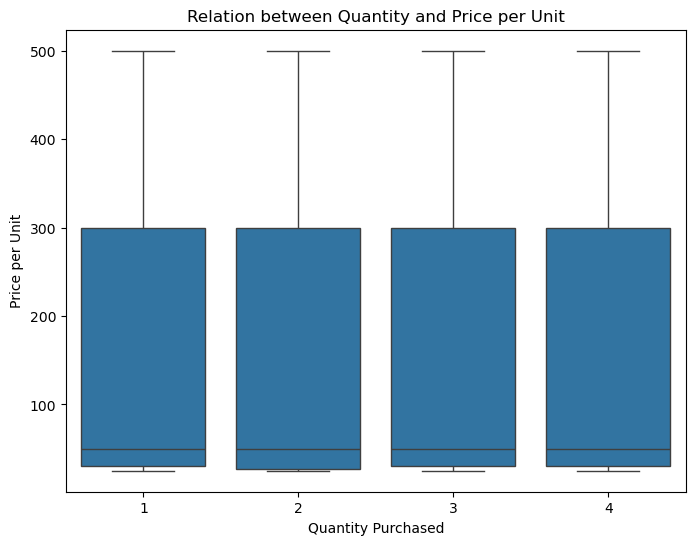

In [40]:
plt.figure(figsize=(8, 6))


sns.boxplot(x='Quantity', y='Price per Unit', data=df)


plt.title('Relation between Quantity and Price per Unit')
plt.xlabel('Quantity Purchased')
plt.ylabel('Price per Unit')


plt.show()

Uniform Pricing: Price distribution, median, and spread are identical across all quantity levels.

No Direct Correlation: Unit price does not change based on how many items are purchased.

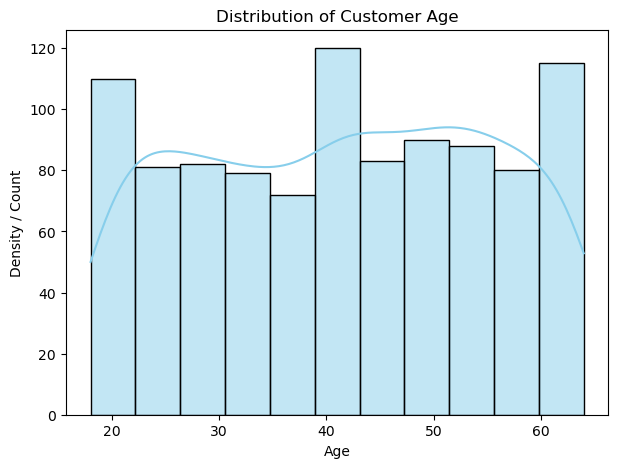

In [41]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Age'], kde=True ,color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Density / Count')
plt.show()

Even Age Distribution: Customer ages are well-spread across all age brackets from 18 to 64 without a single dominant demographic.

Key Peaks: Minor peaks appear in the younger age group (around 20), middle-aged group (around 40), and older adults (around 60).

C:\Users\user\AppData\Local\Temp\ipykernel_14764\1055848329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product Category', data=df, palette='Set2')


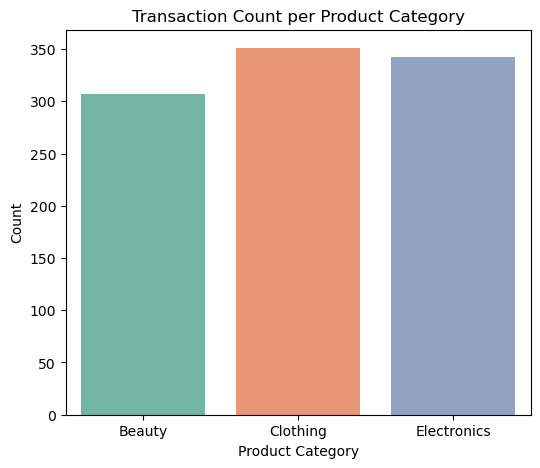

In [42]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Product Category', data=df, palette='Set2')
plt.title('Transaction Count per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()

Balanced Transaction Volume: Transactions are fairly well-distributed across all three categories, with Clothing leading slightly, followed closely by Electronics and Beauty.

Steady Demand: No single product category overwhelmingly dominates or lags behind in purchase frequency.

C:\Users\user\AppData\Local\Temp\ipykernel_14764\3051899546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount' ,data=df, estimator=sum, palette='muted')


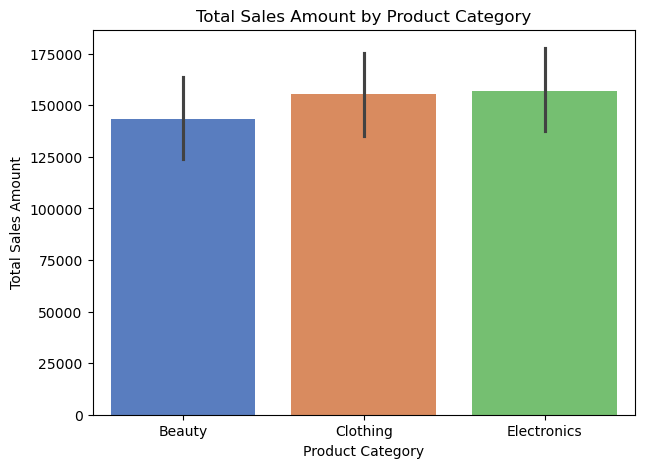

In [43]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Product Category', y='Total Amount' ,data=df, estimator=sum, palette='muted')
plt.title('Total Sales Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.show()

Equal Revenue Generation: All three product categories (Electronics, Clothing, and Beauty) contribute almost identical total sales revenue (around 140,000 to 155,000).

Consistent Financial Impact: No single category dominates profitability or sales volume; each performs equally well in generating overall revenue.

C:\Users\user\AppData\Local\Temp\ipykernel_14764\76919748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Category', y='Price per Unit', data=df, palette='coolwarm')


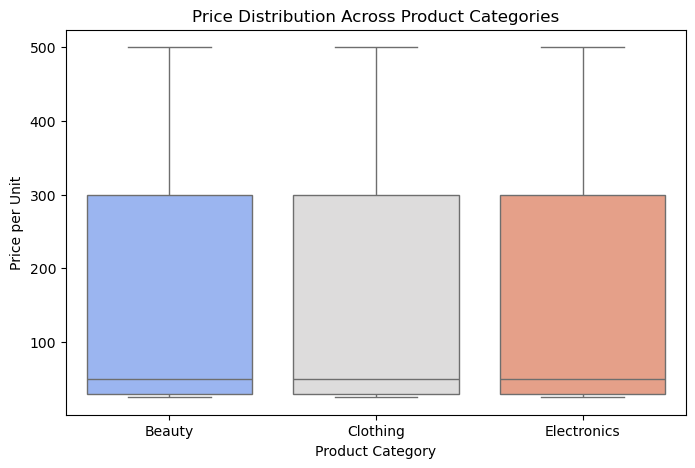

In [44]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Product Category', y='Price per Unit', data=df, palette='coolwarm')
plt.title('Price Distribution Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Price per Unit')
plt.show()

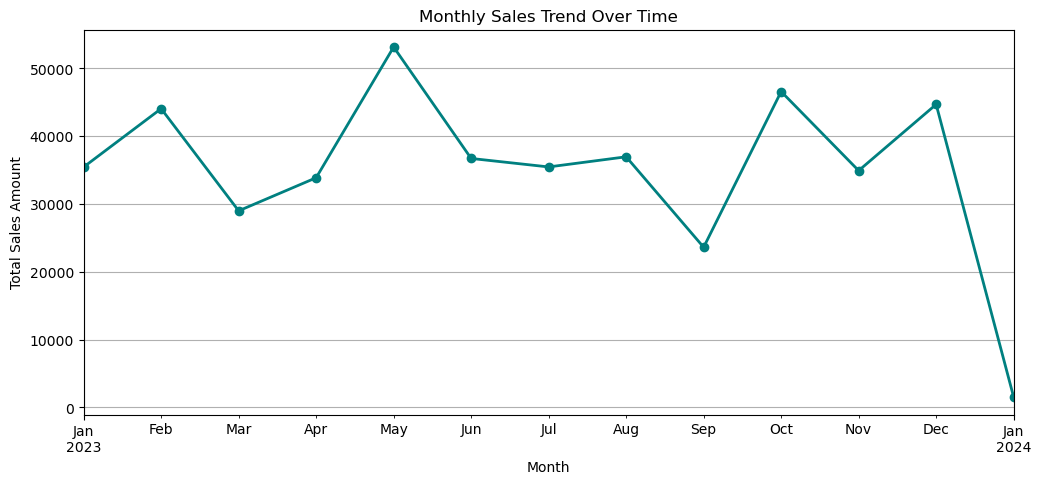

In [45]:
plt.figure(figsize=(12, 5))
# Ensure date is datetime type and sorted
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.set_index('Date')['Total Amount'].resample('ME').sum()

monthly_sales.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.show()

Fluctuating Trend: Monthly sales fluctuate significantly throughout 2023 without a constant upward or downward trajectory.

Peak Sales: The highest sales volume occurs in May, with secondary spikes in October and December.

Dips and Drop: Significant sales drops occur in March and September, culminating in a sharp drop at the very end in January 2024.

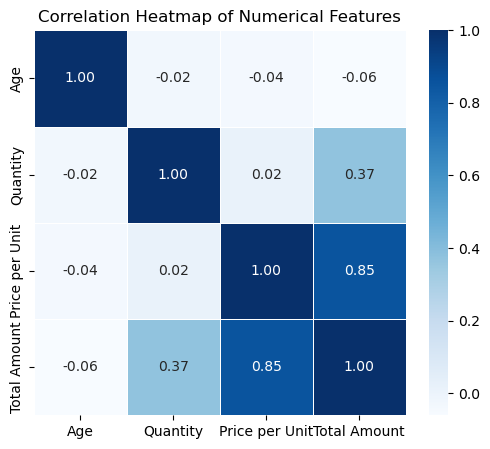

In [46]:
plt.figure(figsize=(6, 5))
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Strongest Driver: Price per Unit has a very strong positive correlation ($0.85$) with Total Amount, meaning it is the primary factor determining total transaction value.Moderate Impact: Quantity shows a moderate positive correlation ($0.37$) with Total Amount, indicating it also plays a secondary role in boosting revenue.No Age Dependency: Age exhibits virtually zero correlation ($\approx 0.00$) with quantity, unit price, or total amount, showing that spending behavior is independent of a customer's age.

## Business Insights And Recommendations

Based on the EDA of the retail transaction dataset (1,000 records, no nulls or duplicates), the Adult segment (18–35) emerges as the most valuable customer group, generating the highest total revenue (171,815) and highest average transaction value (486.73), while gender shows almost no impact on spending (Female avg 456.55 vs Male avg 455.43). Among product categories, electronics stands out for management attention, leading in total revenue (156,905) and average unit price (181.90), whereas beauty is the weakest performer, having the lowest transaction count (307) and lowest total sales (143,515) despite carrying the highest average unit price (184.06), signalling a pricing-demand mismatch worth investigating. Demographically, age shows no correlation with spending value, but younger customers spend more overall, and purchasing patterns are otherwise fairly evenly spread across age groups and categories. The correlation analysis confirms that price per unit is the dominant driver of transaction value (0.85 correlation), followed by quantity (0.37), while age has virtually no influence (≈0.00). Sales also show clear seasonality rather than steady growth, peaking in May with secondary spikes in October and December, and dipping sharply in March, September, and into January. Overall, the key takeaways are that price per unit — not volume or demographics — most strongly drives revenue, beauty underperforms relative to its pricing, and sales fluctuate seasonally rather than trending consistently upward. Based on this, the company should prioritise growing electronics through bundling and upselling, revamp beauty's pricing or promotions to boost volume, target the adult segment with tailored campaigns, align inventory and marketing with seasonal peaks (May, October, and December) while addressing slow months (March and September), and lean on premium pricing strategies over quantity discounts to maximise revenue.

In [47]:
df['Date'] = pd.to_datetime(df['Date']).dt.date

In [48]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Year,Month,Day_Name
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Adult,2023,November,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Adult,2023,February,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Middle Age,2023,January,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Middle Age,2023,May,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Adult,2023,May,Saturday


In [50]:
df.to_csv('cleaned_dataset.csv',index=False)